In [4]:
#!pip install --upgrade numexpr bottleneck pandas

In [5]:
import os
import matplotlib.pyplot as plt
out_dir = os.path.expanduser("~/Desktop/Frontier/fig")
os.makedirs(out_dir, exist_ok=True)

import numpy as np
import pandas as pd
from math import exp
from math import ceil
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
%matplotlib inline

In [ ]:
##SENSITIVITY ANALYSIS

PRCC for R0
Parameter   PRCC_R0
      c_n -0.964655
    gamma -0.957418
     beta  0.797973

PRCC for cumulative infected proportion
Parameter  PRCC_CumulativeI
      c_n         -0.965811
    gamma         -0.937276
     beta          0.784096
      eps          0.323476
       nu         -0.274482
    tau_E         -0.261363
      c_v         -0.021530


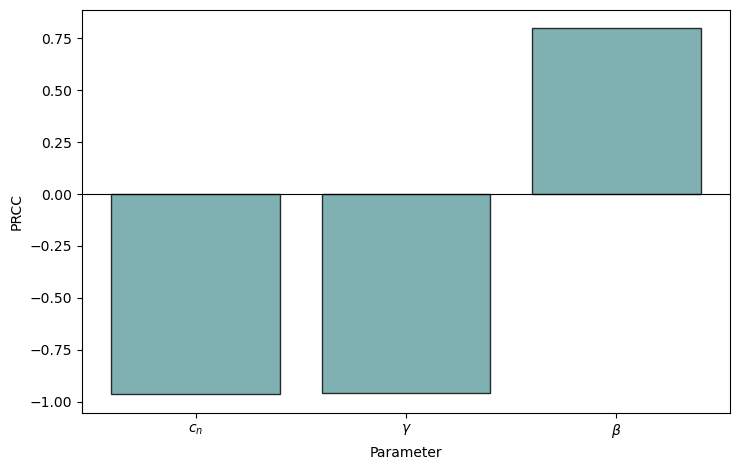

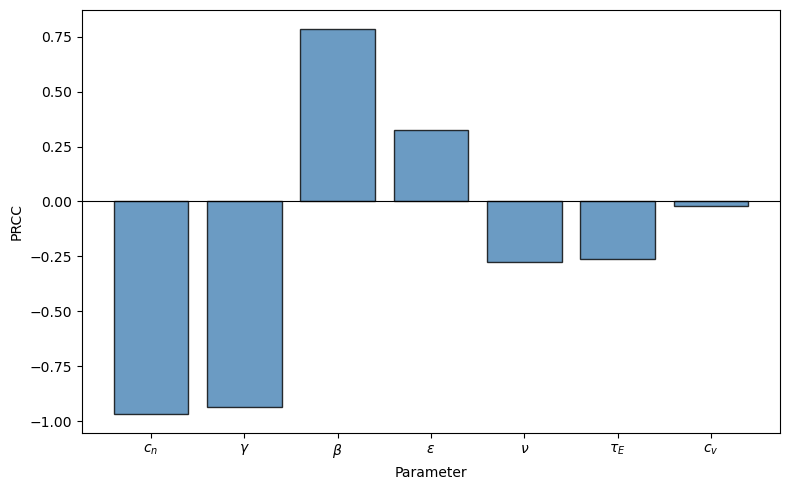

In [6]:
# Mapping for Math Mode Labels
latex_labels = {
    "beta": r"$\beta$",
    "gamma": r"$\gamma$",
    "c_n": r"$c_n$",
    "nu": r"$\nu$",
    "c_v": r"$c_v$",
    "eps": r"$\epsilon$",
    "tau_E": r"$\tau_E$",
    "tau_V": r"$\tau_V$",
    "tau_P": r"$\tau_P$",
}

def lhs_sample(n_samples, bounds, seed=42):
    rng = np.random.default_rng(seed)
    data = {}
    for name, (low, high) in bounds.items():
        cut = np.linspace(0, 1, n_samples + 1)
        u = rng.uniform(cut[:-1], cut[1:])
        rng.shuffle(u)
        data[name] = low + u * (high - low)
    return pd.DataFrame(data)

def simulate_metrics(
    beta,
    gamma,
    c_n,
    nu,
    c_v,
    eps,
    tau_E,
    tau_V=14.0,
    tau_P=60.0,
    T=365.0,
    dt=0.5,
    frac_accepting=0.7,
    I0=1e-5,
):
    N0 = 1.0
    tau = max(tau_E, tau_P + tau_V)
    n_steps = int(round(T / dt))
    n_hist = int(ceil(tau / dt))
    t = np.arange(-n_hist, n_steps + 1) * dt

    Sa = np.zeros_like(t, dtype=float)
    Wa = np.zeros_like(t, dtype=float)
    Pa = np.zeros_like(t, dtype=float)
    Ea = np.zeros_like(t, dtype=float)
    Ia = np.zeros_like(t, dtype=float)
    Ra = np.zeros_like(t, dtype=float)

    Sh = np.zeros_like(t, dtype=float)
    Eh = np.zeros_like(t, dtype=float)
    Ih = np.zeros_like(t, dtype=float)
    Rh = np.zeros_like(t, dtype=float)

    Ia0 = I0 * frac_accepting
    Ih0 = I0 * (1.0 - frac_accepting)
    Sa0 = frac_accepting * N0 - Ia0
    Sh0 = (1.0 - frac_accepting) * N0 - Ih0

    Sa[: n_hist + 1] = Sa0
    Sh[: n_hist + 1] = Sh0
    Ia[: n_hist + 1] = Ia0
    Ih[: n_hist + 1] = Ih0

    lam = np.zeros_like(t, dtype=float)

    def idx_delay(k, delay):
        return k - int(round(delay / dt))

    def survival_factor(k, delay):
        m = int(round(delay / dt))
        if m <= 0:
            return 1.0
        start = max(k - m, 0)
        integral = np.trapz(lam[start : k + 1], dx=dt)
        return np.exp(-integral)

    for k in range(n_hist + 1):
        N = Sa[k] + Wa[k] + Pa[k] + Ea[k] + Ia[k] + Ra[k] + Sh[k] + Eh[k] + Ih[k] + Rh[k]
        lam[k] = beta * (1.0 - c_n) * (Ia[k] + Ih[k]) / max(N, 1e-12)

    for k in range(n_hist, n_hist + n_steps):
        N = Sa[k] + Wa[k] + Pa[k] + Ea[k] + Ia[k] + Ra[k] + Sh[k] + Eh[k] + Ih[k] + Rh[k]
        lam[k] = beta * (1.0 - c_n) * (Ia[k] + Ih[k]) / max(N, 1e-12)

        H_P = 1.0 if t[k] >= tau_P else 0.0
        H_PV = 1.0 if t[k] >= tau_P + tau_V else 0.0

        kE = idx_delay(k, tau_E)
        kV = idx_delay(k, tau_V)

        JV = c_v * nu * H_P * Sa[k]
        JP = 0.0
        if H_PV > 0.0 and kV >= 0:
            JP = c_v * nu * Sa[kV] * survival_factor(k, tau_V)

        delayed_force_a = 0.0
        delayed_force_h = 0.0
        if kE >= 0:
            delayed_force_a = lam[kE] * (Sa[kE] + Wa[kE] + eps * Pa[kE])
            delayed_force_h = lam[kE] * Sh[kE]

        dSa = -lam[k] * Sa[k] - JV
        dWa = JV - lam[k] * Wa[k] - JP
        dPa = JP - eps * lam[k] * Pa[k]
        dEa = lam[k] * (Sa[k] + Wa[k] + eps * Pa[k]) - delayed_force_a
        dIa = delayed_force_a - gamma * Ia[k]
        dRa = gamma * Ia[k]

        dSh = -lam[k] * Sh[k]
        dEh = lam[k] * Sh[k] - delayed_force_h
        dIh = delayed_force_h - gamma * Ih[k]
        dRh = gamma * Ih[k]

        Sa[k + 1] = max(Sa[k] + dt * dSa, 0.0)
        Wa[k + 1] = max(Wa[k] + dt * dWa, 0.0)
        Pa[k + 1] = max(Pa[k] + dt * dPa, 0.0)
        Ea[k + 1] = max(Ea[k] + dt * dEa, 0.0)
        Ia[k + 1] = max(Ia[k] + dt * dIa, 0.0)
        Ra[k + 1] = max(Ra[k] + dt * dRa, 0.0)

        Sh[k + 1] = max(Sh[k] + dt * dSh, 0.0)
        Eh[k + 1] = max(Eh[k] + dt * dEh, 0.0)
        Ih[k + 1] = max(Ih[k] + dt * dIh, 0.0)
        Rh[k + 1] = max(Rh[k] + dt * dRh, 0.0)

    I = Ia + Ih
    R = Ra + Rh
    peak_I = float(np.max(I[n_hist:]))
    cumulative_I = float(R[n_hist:][-1])
    return peak_I, cumulative_I

def rank_transform(x):
    return pd.Series(x).rank(method="average").to_numpy()

def prcc(df_params, y):
    X_rank = np.column_stack([rank_transform(df_params[col].to_numpy()) for col in df_params.columns])
    y_rank = rank_transform(y)

    n, p = X_rank.shape
    results = {}
    ones = np.ones((n, 1))

    for j, name in enumerate(df_params.columns):
        idx_other = [i for i in range(p) if i != j]
        Z = np.hstack([ones, X_rank[:, idx_other]])

        coef_x, *_ = np.linalg.lstsq(Z, X_rank[:, j], rcond=None)
        resid_x = X_rank[:, j] - Z @ coef_x

        coef_y, *_ = np.linalg.lstsq(Z, y_rank, rcond=None)
        resid_y = y_rank - Z @ coef_y

        results[name] = np.corrcoef(resid_x, resid_y)[0, 1]
    return pd.Series(results)

bounds_R0 = {
    "beta": (1.3 * 0.2 / (1.0 - 0.40), 2.0 * 0.2 / (1.0 - 0.40)),
    "gamma": (0.1, 0.3),
    "c_n": (0.00, 0.70),
}

bounds_burden = {
    "beta": (1.3 * 0.2 / (1.0 - 0.40), 2.0 * 0.2 / (1.0 - 0.40)),
    "gamma": (0.1, 0.3),
    "c_n": (0.00, 0.70),
    "nu": (0.005, 0.05),
    "c_v": (0.50, 0.90),
    "eps": (0.20, 0.70),
    "tau_E": (1.0, 4.0),
}

samples_R0 = lhs_sample(600, bounds_R0, seed=11)
samples_burden = lhs_sample(600, bounds_burden, seed=13)

R0_vals = samples_R0["beta"] * (1.0 - samples_R0["c_n"]) / samples_R0["gamma"]

peak_vals = []
cum_vals = []
for _, row in samples_burden.iterrows():
    p, c = simulate_metrics(
        beta=float(row["beta"]),
        gamma=float(row["gamma"]),
        c_n=float(row["c_n"]),
        nu=float(row["nu"]),
        c_v=float(row["c_v"]),
        eps=float(row["eps"]),
        tau_E=float(row["tau_E"]),
        tau_V=14.0,
        tau_P=60.0,
    )
    peak_vals.append(p)
    cum_vals.append(c)

peak_vals = np.array(peak_vals)
cum_vals = np.array(cum_vals)

prcc_R0 = prcc(samples_R0, R0_vals)
prcc_cum = prcc(samples_burden, cum_vals)

print("PRCC for R0")
print(pd.DataFrame({"Parameter": prcc_R0.index, "PRCC_R0": prcc_R0.values}).sort_values("PRCC_R0", key=np.abs, ascending=False).to_string(index=False))

print("\nPRCC for cumulative infected proportion")
print(pd.DataFrame({"Parameter": prcc_cum.index, "PRCC_CumulativeI": prcc_cum.values}).sort_values("PRCC_CumulativeI", key=np.abs, ascending=False).to_string(index=False))


# Rename indices to Math Mode for plotting
prcc_R0_math = prcc_R0.rename(index=latex_labels)
prcc_cum_math = prcc_cum.rename(index=latex_labels)

# =========================
# FIGURE: Sensitivity of R0 
# =========================
order_r0 = prcc_R0_math.abs().sort_values(ascending=False).index
fig_r0, ax_r0 = plt.subplots(figsize=(7.5, 4.8))

ax_r0.bar(order_r0, prcc_R0_math[order_r0], color='cadetblue', alpha=0.8, edgecolor='black')
ax_r0.axhline(0, color='black', linewidth=0.8)
ax_r0.set_ylabel("PRCC")
ax_r0.set_xlabel("Parameter")
#ax_r0.set_title(r"PRCC sensitivity of $\mathcal{R}_0$")

fig_r0.tight_layout()
fig_r0.savefig(os.path.join(out_dir, "sensitivity_R0.png"), dpi=600)

# =========================
# FIGURE: Sensitivity of Cumulative 
# =========================
order_cum = prcc_cum_math.abs().sort_values(ascending=False).index
fig_cum, ax_cum = plt.subplots(figsize=(8, 5))

ax_cum.bar(order_cum, prcc_cum_math[order_cum], color='steelblue', alpha=0.8, edgecolor='black')
ax_cum.axhline(0, color='black', linewidth=0.8)
ax_cum.set_ylabel("PRCC")
ax_cum.set_xlabel("Parameter")
#ax_cum.set_title("PRCC sensitivity of cumulative infected proportion")

fig_cum.tight_layout()
fig_cum.savefig(os.path.join(out_dir, "sensitivity_cum.png"), dpi=600)

plt.show()


In [7]:
# =========================
# MODEL SIMULATION FUNCTION
# =========================

def simulate_hpai_full(
    T=365.0,
    dt=0.1,
    N0=340110988.0,
    q_accept=0.70,
    I0_total=13.0,
    R0=1.7,
    cn=0.40,
    gamma=0.2,
    nu=0.02,
    cv=0.70,
    epsilon=0.40,
    tauE=2.0,
    tauV=14.0,
    tauP=120.0,
    verbose=False
):
    """
    Simulate the full HPAI transmission model with vaccination delays.
    """
    
    # Calculate beta from R0
    beta = (R0 * gamma) / (1.0 - cn)
    
    # Time array
    times = np.arange(0.0, T + dt, dt)
    n = len(times)
    
    # Population splitting
    Na0 = q_accept * N0
    Nh0 = (1.0 - q_accept) * N0
    
    I0a = I0_total * q_accept
    I0h = I0_total * (1.0 - q_accept)
    
    Sa0 = Na0 - I0a
    Sh0 = Nh0 - I0h
    
    # Initialize state variables
    Sa = np.zeros(n)
    Wa = np.zeros(n)
    Pa = np.zeros(n)
    Ea = np.zeros(n)
    Ia = np.zeros(n)
    Ra = np.zeros(n)
    
    Sh = np.zeros(n)
    Eh = np.zeros(n)
    Ih = np.zeros(n)
    Rh = np.zeros(n)
    
    # Set initial conditions
    Sa[0] = Sa0
    Sh[0] = Sh0
    Ia[0] = I0a
    Ih[0] = I0h
    
    # Track force of infection and integrals
    lam = np.zeros(n)
    
    # Main simulation loop
    for k in range(n - 1):
        # Total population
        N = Sa[k] + Wa[k] + Pa[k] + Ea[k] + Ia[k] + Ra[k] + Sh[k] + Eh[k] + Ih[k] + Rh[k]
        
        # Force of infection
        lam[k] = beta * (1.0 - cn) * (Ia[k] + Ih[k]) / max(N, 1e-12)
        
        # Heaviside functions for vaccination
        H_tauP = 1.0 if times[k] >= tauP else 0.0
        H_tauP_tauV = 1.0 if times[k] >= (tauP + tauV) else 0.0
        
        # Calculate survival probability for vaccinated individuals
        survival_prob = 1.0
        if k >= int(tauV / dt):
            k_start = k - int(tauV / dt)
            integral = np.trapz(lam[k_start:k+1], times[k_start:k+1])
            survival_prob = exp(-integral)
        
        # Delayed terms for infection
        kE = k - int(tauE / dt)
        delayed_infections_a = 0.0
        delayed_infections_h = 0.0
        
        if kE >= 0:
            delayed_infections_a = lam[kE] * (Sa[kE] + Wa[kE] + epsilon * Pa[kE])
            delayed_infections_h = lam[kE] * Sh[kE]
        
        # Delayed vaccination term
        delayed_vaccination = 0.0
        if k >= int((tauP + tauV) / dt):
            k_delay = k - int((tauP + tauV) / dt)
            if k_delay >= 0:
                survival_prob_delayed = 1.0
                if k_delay >= int(tauV / dt):
                    k_start = k_delay - int(tauV / dt)
                    if k_start >= 0:
                        integral = np.trapz(lam[k_start:k_delay+1], times[k_start:k_delay+1])
                        survival_prob_delayed = exp(-integral)
                delayed_vaccination = cv * nu * H_tauP_tauV * Sa[k_delay] * survival_prob_delayed
        
        # Differential equations for accepting group
        dSa = -lam[k] * Sa[k] - cv * nu * H_tauP * Sa[k]
        dWa = cv * nu * H_tauP * Sa[k] - lam[k] * Wa[k] - delayed_vaccination
        dPa = delayed_vaccination - epsilon * lam[k] * Pa[k]
        dEa = lam[k] * (Sa[k] + Wa[k] + epsilon * Pa[k]) - delayed_infections_a
        dIa = delayed_infections_a - gamma * Ia[k]
        dRa = gamma * Ia[k]
        
        # Differential equations for hesitant group
        dSh = -lam[k] * Sh[k]
        dEh = lam[k] * Sh[k] - delayed_infections_h
        dIh = delayed_infections_h - gamma * Ih[k]
        dRh = gamma * Ih[k]
        
        # Update using Euler method
        Sa[k+1] = Sa[k] + dt * dSa
        Wa[k+1] = Wa[k] + dt * dWa
        Pa[k+1] = Pa[k] + dt * dPa
        Ea[k+1] = Ea[k] + dt * dEa
        Ia[k+1] = Ia[k] + dt * dIa
        Ra[k+1] = Ra[k] + dt * dRa
        
        Sh[k+1] = Sh[k] + dt * dSh
        Eh[k+1] = Eh[k] + dt * dEh
        Ih[k+1] = Ih[k] + dt * dIh
        Rh[k+1] = Rh[k] + dt * dRh
    
    # Calculate metrics
    I_total = Ia + Ih
    cumulative_infected = (Ra + Rh) #/ N0
    peak_infectious = np.max(I_total)# / N0
    peak_day = times[np.argmax(I_total)]
    attack_rate = (Ra[-1] + Rh[-1]) #/ N0
    
    compartments = {
        'Sa': Sa, 'Wa': Wa, 'Pa': Pa, 'Ea': Ea, 'Ia': Ia, 'Ra': Ra,
        'Sh': Sh, 'Eh': Eh, 'Ih': Ih, 'Rh': Rh,
        'I_total': I_total, 'lambda': lam, 'times': times
    }
    
    if verbose:
        print(f"R0: {R0:.2f}, Beta: {beta:.4f}")
        print(f"Peak infectious: {peak_infectious:.4f} at day {peak_day:.1f}")
        print(f"Attack rate: {attack_rate:.4f}")
    
    return compartments, peak_infectious, attack_rate, peak_day

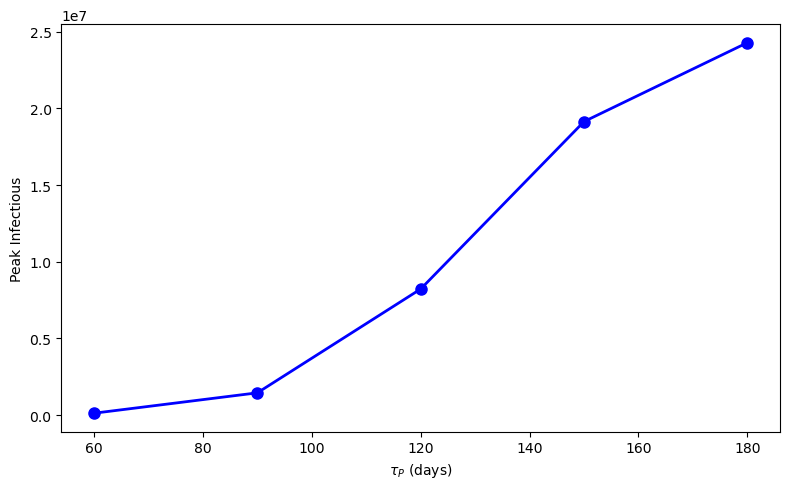

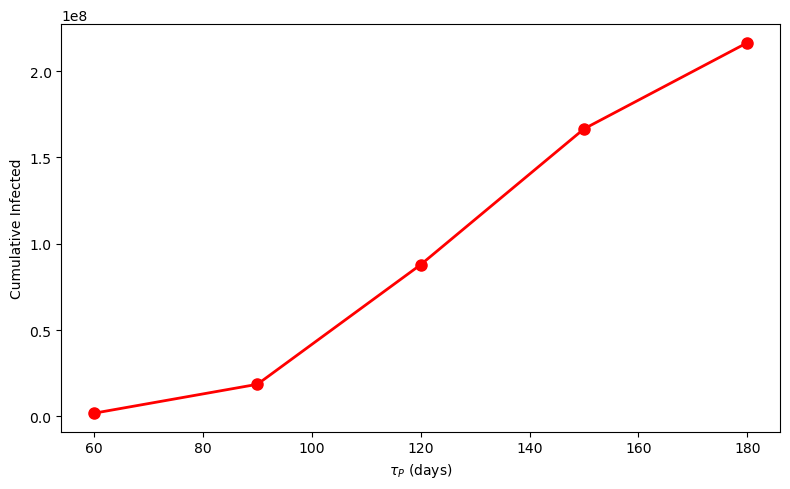

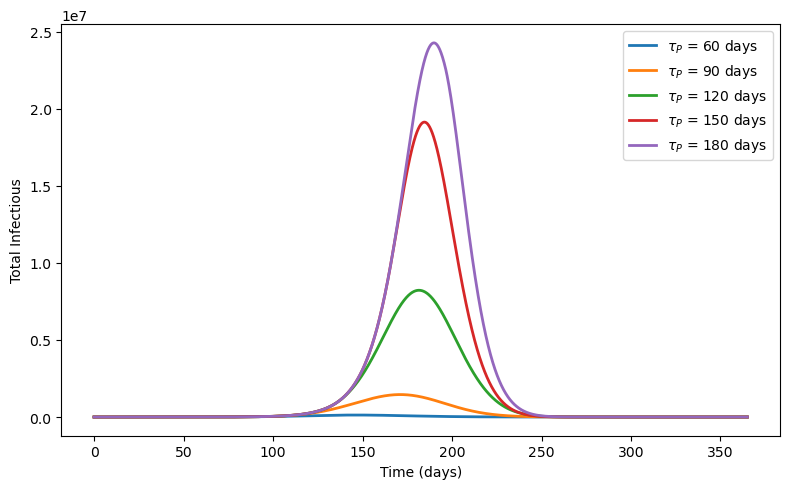

In [8]:
# =========================
# CELL 1: EFFECT OF PRE-DEPLOYMENT DELAY (τ_p)
# =========================



tauP_values = [60, 90, 120, 150, 180]
peak_props = []
attack_rates = []

# Create figure objects
fig1a, ax1a = plt.subplots(figsize=(8, 5))
fig1b, ax1b = plt.subplots(figsize=(8, 5))
fig1c, ax1c = plt.subplots(figsize=(8, 5))

for tauP in tauP_values:
    comp, peak, attack, _ = simulate_hpai_full(tauP=tauP, verbose=False)
    peak_props.append(peak)
    attack_rates.append(attack)
    ax1c.plot(comp['times'], comp['I_total'], linewidth=2, label=f'$\\tau_P$ = {tauP} days')

# --- Plot and Save Figure 1a ---
ax1a.plot(tauP_values, peak_props, 'bo-', linewidth=2, markersize=8)
ax1a.set_xlabel(r"$\tau_P$ (days)")
ax1a.set_ylabel(r"Peak Infectious")
fig1a.tight_layout()
#fig1a.savefig(os.path.join(out_dir, "tau_P_peak.png"), dpi=600)

# --- Plot and Save Figure 1b ---
ax1b.plot(tauP_values, attack_rates, 'ro-', linewidth=2, markersize=8)
ax1b.set_xlabel(r"$\tau_P$ (days)")
ax1b.set_ylabel(r"Cumulative Infected")
fig1b.tight_layout()
#fig1b.savefig(os.path.join(out_dir, "tau_P_cum.png"), dpi=600)

# --- Plot and Save Figure 1c ---
ax1c.set_xlabel(r"Time (days)")
ax1c.set_ylabel(r"Total Infectious")
ax1c.legend(fontsize=10, loc='upper right')
fig1c.tight_layout()
#fig1c.savefig(os.path.join(out_dir, "tau_P_tot.png"), dpi=600)

plt.show()


Simulating τ_E = 1 days...
Simulating τ_E = 2 days...
Simulating τ_E = 3 days...
Simulating τ_E = 4 days...
Simulating τ_E = 5 days...


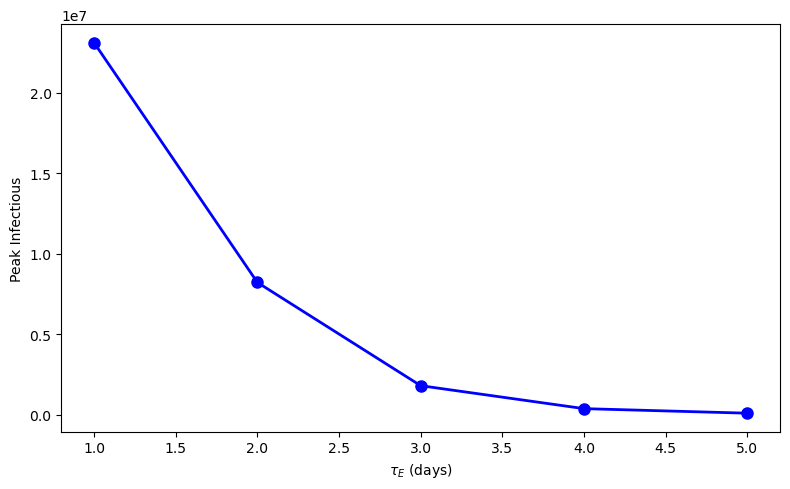

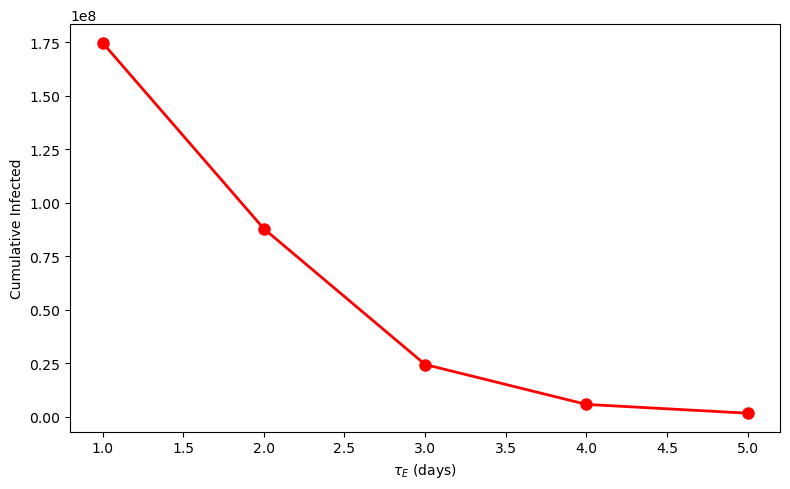

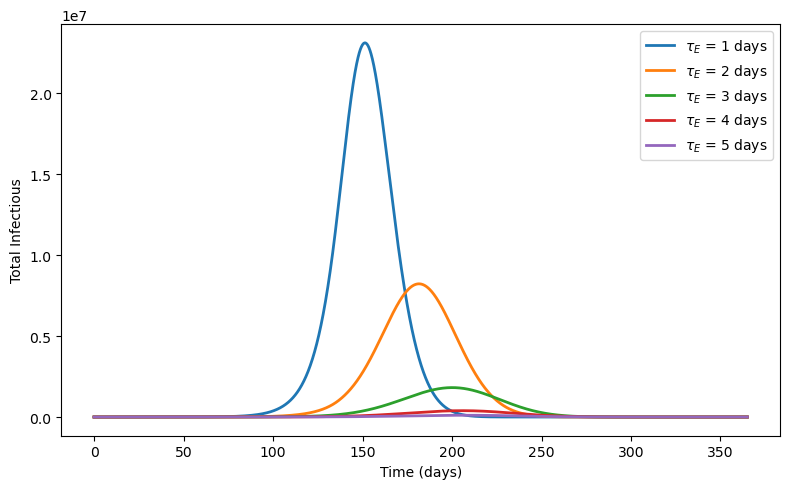

In [61]:
# =========================
# CELL 2: EFFECT OF INCUBATION DELAY (τ_E)
# =========================


tauE_values = [1, 2, 3, 4, 5]
peak_props = []
attack_rates = []

fig1a, ax1a = plt.subplots(figsize=(8, 5))
fig1b, ax1b = plt.subplots(figsize=(8, 5))
fig1c, ax1c = plt.subplots(figsize=(8, 5))

for tauE in tauE_values:
    print(f"Simulating τ_E = {tauE} days...")
    comp, peak, attack, _ = simulate_hpai_full(tauE=tauE, verbose=False)
    peak_props.append(peak)
    attack_rates.append(attack)
    ax1c.plot(comp['times'], comp['I_total'],# / 340110988.0, 
              linewidth=2, label=f'$\\tau_E$ = {tauE} days')# --- Plot and Save Figure 1a ---
ax1a.plot(tauE_values, peak_props, 'bo-', linewidth=2, markersize=8)
ax1a.set_xlabel(r"$\tau_E$ (days)")
ax1a.set_ylabel(r"Peak Infectious")
fig1a.tight_layout()
fig1a.savefig(os.path.join(out_dir, "tau_E_peak.png"), dpi=600)

# --- Plot and Save Figure 1b ---
ax1b.plot(tauE_values, attack_rates, 'ro-', linewidth=2, markersize=8)
ax1b.set_xlabel(r"$\tau_E$ (days)")
ax1b.set_ylabel(r"Cumulative Infected")
fig1b.tight_layout()
fig1b.savefig(os.path.join(out_dir, "tau_E_cum.png"), dpi=600)

# --- Plot and Save Figure 1c ---
ax1c.set_xlabel(r"Time (days)")
ax1c.set_ylabel(r"Total Infectious")
ax1c.legend(fontsize=10, loc='upper right')
fig1c.tight_layout()
fig1c.savefig(os.path.join(out_dir, "tau_E_tot.png"), dpi=600)

plt.show()

Simulating τ_V = 7 days...
Simulating τ_V = 14 days...
Simulating τ_V = 21 days...
Simulating τ_V = 28 days...
Simulating τ_V = 35 days...


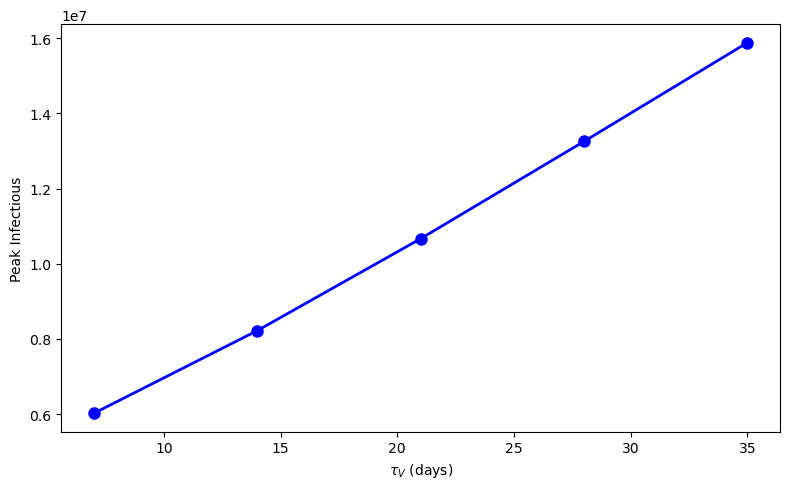

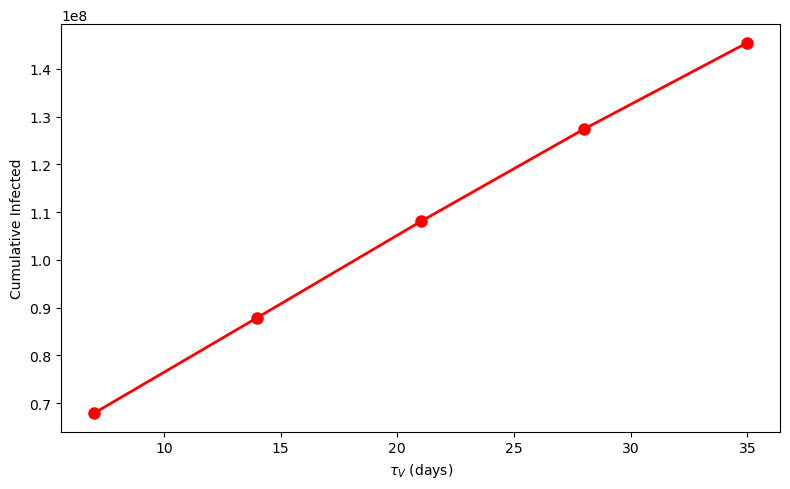

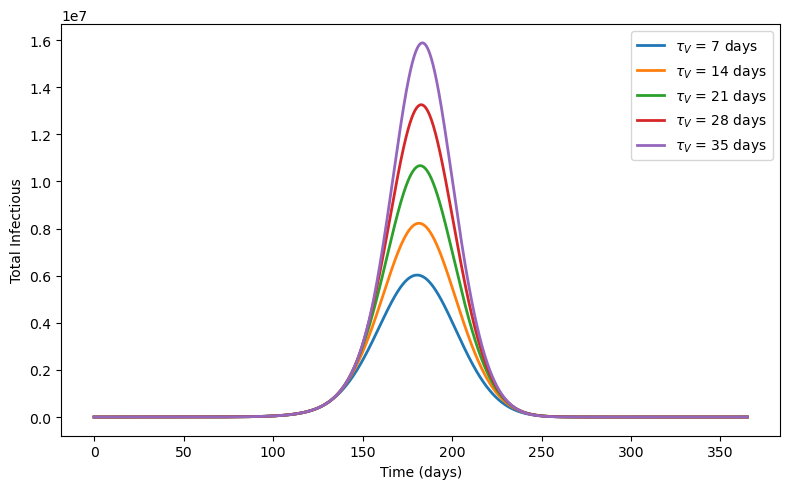

In [9]:
# =========================
# CELL 3: EFFECT OF VACCINE-TO-PROTECTION DELAY (τ_V)
# =========================

tauV_values = [7, 14, 21, 28, 35]
peak_props = []
attack_rates = []

fig1a, ax1a = plt.subplots(figsize=(8, 5))
fig1b, ax1b = plt.subplots(figsize=(8, 5))
fig1c, ax1c = plt.subplots(figsize=(8, 5))

for tauV in tauV_values:
    print(f"Simulating τ_V = {tauV} days...")
    comp, peak, attack, _ = simulate_hpai_full(tauV=tauV, verbose=False)
    peak_props.append(peak)
    attack_rates.append(attack)
    ax1c.plot(comp['times'], comp['I_total'],# / 340110988.0, 
              linewidth=2, label=f'$\\tau_V$ = {tauV} days')# --- Plot and Save Figure 1a ---
ax1a.plot(tauV_values, peak_props, 'bo-', linewidth=2, markersize=8)
ax1a.set_xlabel(r"$\tau_V$ (days)")
ax1a.set_ylabel(r"Peak Infectious")
fig1a.tight_layout()
#fig1a.savefig(os.path.join(out_dir, "tau_V_peak.png"), dpi=600)

# --- Plot and Save Figure 1b ---
ax1b.plot(tauV_values, attack_rates, 'ro-', linewidth=2, markersize=8)
ax1b.set_xlabel(r"$\tau_V$ (days)")
ax1b.set_ylabel(r"Cumulative Infected")
fig1b.tight_layout()
#fig1b.savefig(os.path.join(out_dir, "tau_V_cum.png"), dpi=600)

# --- Plot and Save Figure 1c ---
ax1c.set_xlabel(r"Time (days)")
ax1c.set_ylabel(r"Total Infectious")
ax1c.legend(fontsize=10, loc='upper right')
fig1c.tight_layout()
#fig1c.savefig(os.path.join(out_dir, "tau_V_tot.png"), dpi=600)

plt.show()

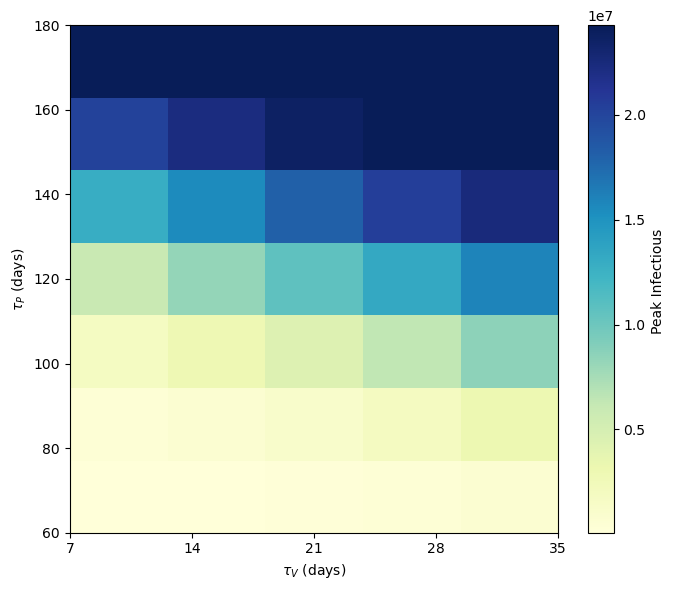

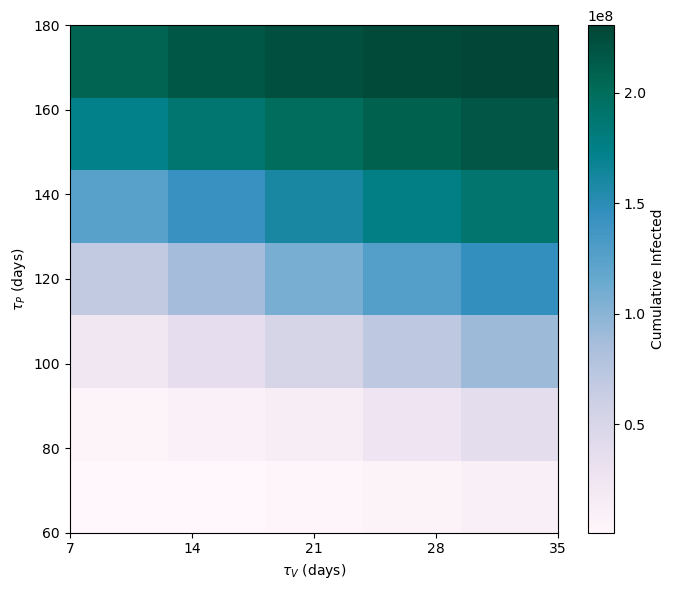

In [10]:
# =========================
# CELL 4: COMBINED EFFECTS OF τ_P AND τ_V - SEPARATE HEATMAPS
# =========================

tauP_grid = np.arange(60, 181, 20)
tauV_grid = np.arange(7, 36, 7)
peak_matrix = np.zeros((len(tauP_grid), len(tauV_grid)))
attack_matrix = np.zeros((len(tauP_grid), len(tauV_grid)))

for i, tauP in enumerate(tauP_grid):
    for j, tauV in enumerate(tauV_grid):
        _, peak, attack, _ = simulate_hpai_full(tauP=tauP, tauV=tauV, verbose=False)
        peak_matrix[i, j] = peak
        attack_matrix[i, j] = attack

extent = [min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)]
cool_cmap = 'YlGnBu'

# --- FIGURE 1: Peak Infectious ---
fig4a, ax4a = plt.subplots(figsize=(7, 6)) # Individual figure
im1 = ax4a.imshow(peak_matrix, cmap=cool_cmap, aspect='auto', origin='lower', extent=extent)
ax4a.set_xlabel(r"$\tau_V$ (days)")
ax4a.set_ylabel(r"$\tau_P$ (days)")
ax4a.set_xticks(tauV_grid)
ax4a.set_yticks(tauP_grid)
plt.colorbar(im1, ax=ax4a, label='Peak Infectious ')
fig4a.tight_layout()
#fig4a.savefig(os.path.join(out_dir, "combined_peak.png"), dpi=600)

# --- FIGURE 2: Cumulative Infected ---
fig4b, ax4b = plt.subplots(figsize=(7, 6)) # Second individual figure
im2 = ax4b.imshow(attack_matrix, cmap='PuBuGn', aspect='auto', origin='lower', extent=extent)
ax4b.set_xlabel(r"$\tau_V$ (days)")
ax4b.set_ylabel(r"$\tau_P$ (days)")
ax4b.set_xticks(tauV_grid)
ax4b.set_yticks(tauP_grid)
plt.colorbar(im2, ax=ax4b, label='Cumulative Infected')
fig4b.tight_layout()
#fig4b.savefig(os.path.join(out_dir, "combined_cum.png"), dpi=600)

plt.show()


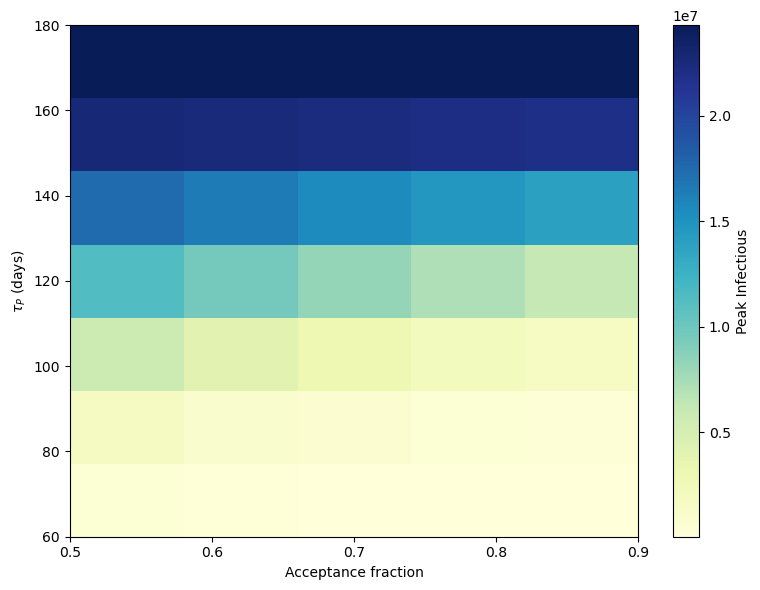

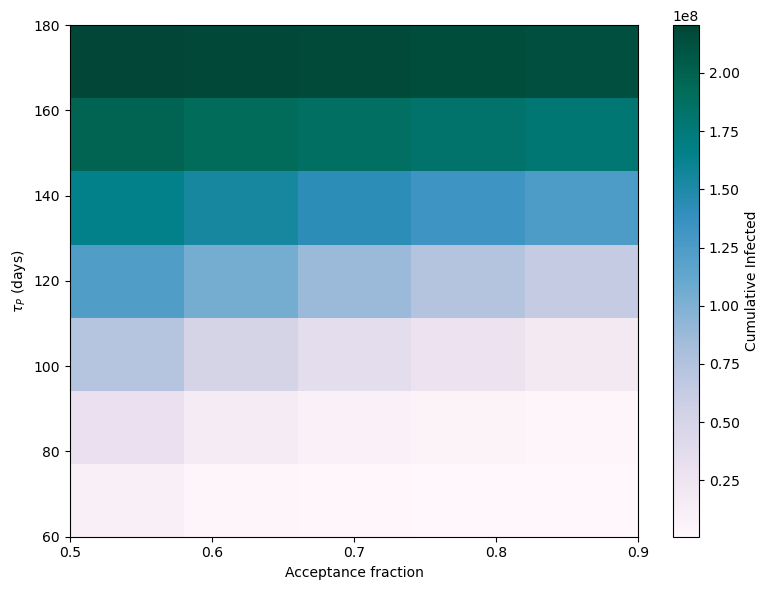

In [12]:
# =========================
# CELL 5: VACCINATION ACCEPTANCE VS PRE-DEPLOYMENT DELAY - HEATMAPS
# =========================

# Grid setup
tauP_grid = np.arange(60, 181, 20)
acceptance_grid = np.arange(0.5, 0.91, 0.1)
peak_acceptance_matrix = np.zeros((len(tauP_grid), len(acceptance_grid)))
attack_acceptance_matrix = np.zeros((len(tauP_grid), len(acceptance_grid)))

# Simulation loop 
for i, tauP in enumerate(tauP_grid):
    for j, q_accept in enumerate(acceptance_grid):
        _, peak, attack, _ = simulate_hpai_full(tauP=tauP, q_accept=q_accept, verbose=False)
        peak_acceptance_matrix[i, j] = peak
        attack_acceptance_matrix[i, j] = attack

# Shared settings
extent = [min(acceptance_grid), max(acceptance_grid), min(tauP_grid), max(tauP_grid)]
xticks = np.arange(0.5, 0.91, 0.1)
yticks = tauP_grid

# =========================
# FIGURE 5a: Peak Infectious (Cool Palette 1)
# =========================
fig5a, ax5a = plt.subplots(figsize=(8, 6))
im1 = ax5a.imshow(peak_acceptance_matrix, cmap='YlGnBu', aspect='auto', origin='lower',
                  extent=extent)
ax5a.set_xlabel(r"Acceptance fraction")
ax5a.set_ylabel(r"$\tau_P$ (days)")
ax5a.set_xticks(xticks)
ax5a.set_yticks(yticks)
plt.colorbar(im1, ax=ax5a, label='Peak Infectious')

fig5a.tight_layout()
#fig5a.savefig(os.path.join(out_dir, "peak_interaction.png"), dpi=600)

# =========================
# FIGURE 5b: Cumulative Infected (Cool Palette 2)
# =========================
fig5b, ax5b = plt.subplots(figsize=(8, 6))
im2 = ax5b.imshow(attack_acceptance_matrix, cmap='PuBuGn', aspect='auto', origin='lower',
                  extent=extent)
ax5b.set_xlabel(r"Acceptance fraction")
ax5b.set_ylabel(r"$\tau_P$ (days)")
ax5b.set_xticks(xticks)
ax5b.set_yticks(yticks)
#ax5b.set_title("Cumulative Infected Proportion")
plt.colorbar(im2, ax=ax5b, label='Cumulative Infected')

fig5b.tight_layout()
#fig5b.savefig(os.path.join(out_dir, "cum_interacion.png"), dpi=600)

plt.show()


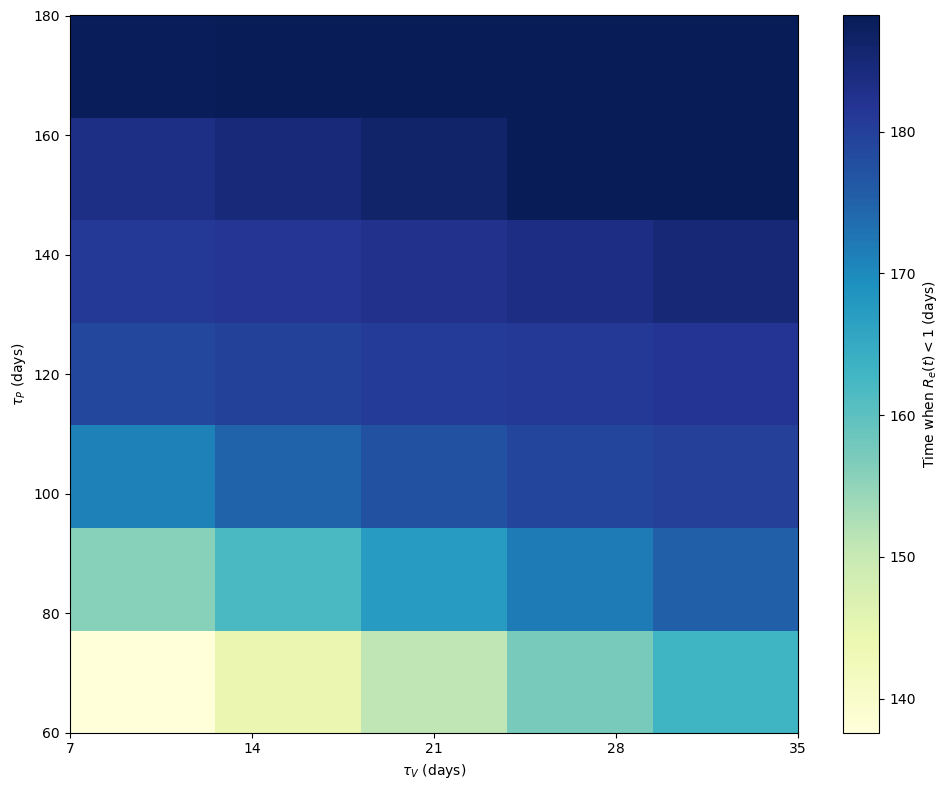

In [11]:
# =========================
# CELL 6: EFFECTIVE REPRODUCTION NUMBER - HEATMAP
# =========================

def calculate_Re_threshold(tauP, tauV):
    """Calculate the time when Re drops below 1 for given delays"""
    comp, _, _, _ = simulate_hpai_full(tauP=tauP, tauV=tauV, verbose=False)
    
    times = comp['times']
    N_total = 340110988.0
    R0 = 1.7
    
    # Calculate Re(t)
    Re = np.zeros_like(times)
    for k in range(len(times)):
        Sa = comp['Sa'][k]
        Wa = comp['Wa'][k]
        Pa = comp['Pa'][k]
        Sh = comp['Sh'][k]
        Ntot = (comp['Sa'][k] + comp['Wa'][k] + comp['Pa'][k] + comp['Ea'][k] + 
                comp['Ia'][k] + comp['Ra'][k] + comp['Sh'][k] + comp['Eh'][k] + 
                comp['Ih'][k] + comp['Rh'][k])
        
        # Re = R0 * (Sa + Wa + epsp * Pa + Sh) / Ntot
        Re[k] = R0 * (Sa + Wa + 0.4 * Pa + Sh) / max(Ntot, 1e-12)
    
    # Find first time when Re < 1
    threshold_time = None
    for k in range(len(times)):
        if Re[k] < 1:
            threshold_time = times[k]
            break
    
    return threshold_time if threshold_time is not None else 365

# Create heatmap
tauP_grid = np.arange(60, 181, 20)
tauV_grid = np.arange(7, 36, 7)
threshold_matrix = np.zeros((len(tauP_grid), len(tauV_grid)))

for i, tauP in enumerate(tauP_grid):
    for j, tauV in enumerate(tauV_grid):
        #print(f"Calculating for τ_P={tauP}, τ_V={tauV}...")
        threshold_matrix[i, j] = calculate_Re_threshold(tauP, tauV)

fig6, ax6 = plt.subplots(figsize=(10, 8))

im = ax6.imshow(threshold_matrix, cmap='YlGnBu', aspect='auto', origin='lower',
                extent=[min(tauV_grid), max(tauV_grid), min(tauP_grid), max(tauP_grid)])
ax6.set_xlabel(r"$\tau_V$ (days)")
ax6.set_ylabel(r"$\tau_P$ (days)")
xticks = list(range(7, 36, 7))
ax6.set_xticks(xticks)
yticks = list(range(60, 181, 20))
ax6.set_yticks(yticks)
plt.colorbar(im, ax=ax6, label='Time when $R_e(t) < 1$ (days)')
#fig6.savefig(os.path.join(out_dir, "time_cross.png"), dpi=600)
plt.tight_layout()
plt.show()

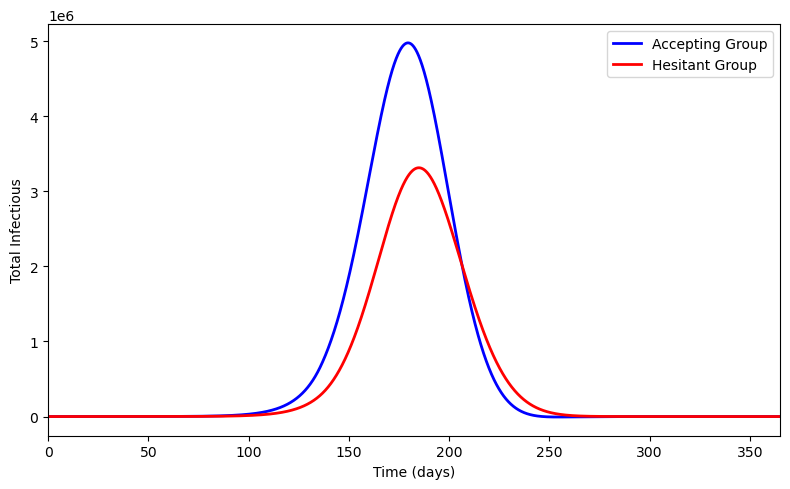

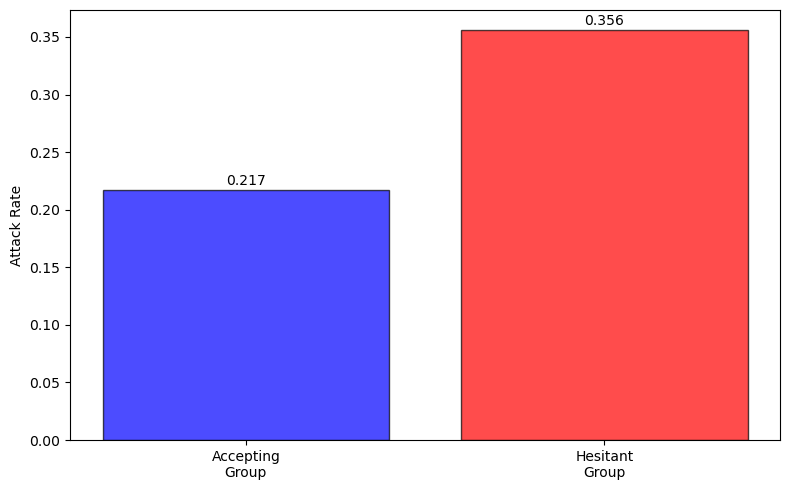

In [13]:
# =========================
# CELL 7: INFECTIOUS DYNAMICS AND GROUP-SPECIFIC BURDEN 
# =========================

# Run baseline simulation
comp, peak, attack, _ = simulate_hpai_full(verbose=False)
times = comp['times']
N_total = 340110988.0

# Colors for "Cool" palette
color_accepting = 'blue'#'#1f77b4' # Deep Blue
color_hesitant = 'red'#'#40E0D0'  # Turquoise/Teal

# --- FIGURE 7a: Infectious Dynamics ---
fig7a, ax7a = plt.subplots(figsize=(8, 5))
ax7a.plot(times, comp['Ia'], 'b-', linewidth=2, label='Accepting Group')#/ N_total
ax7a.plot(times, comp['Ih'], 'r-', linewidth=2, label='Hesitant Group')
ax7a.set_xlabel(r"Time (days)")
ax7a.set_ylabel(r"Total Infectious")
ax7a.legend(fontsize=10)
ax7a.set_xlim(0, 365)



fig7a.tight_layout()
#fig7a.savefig(os.path.join(out_dir, "group_inf.png"), dpi=600)

# --- FIGURE 7b: Attack Rates Bar Chart ---
fig7b, ax7b = plt.subplots(figsize=(8, 5))
attack_accepting = (comp['Ra'][-1] / (0.7 * N_total))
attack_hesitant = (comp['Rh'][-1] / (0.3 * N_total))

bars = ax7b.bar(['Accepting\nGroup', 'Hesitant\nGroup'], 
                [attack_accepting, attack_hesitant], 
                color=['blue','red'], alpha=0.7, edgecolor='black')
ax7b.set_ylabel(r"Attack Rate")


# Add value labels on bars
ax7b.text(0, attack_accepting + 0.005, f'{attack_accepting:.3f}', ha='center', fontsize=10)
ax7b.text(1, attack_hesitant + 0.005, f'{attack_hesitant:.3f}', ha='center', fontsize=10)

fig7b.tight_layout()
#fig7b.savefig(os.path.join(out_dir, "attack_rate.png"), dpi=600)

plt.show()


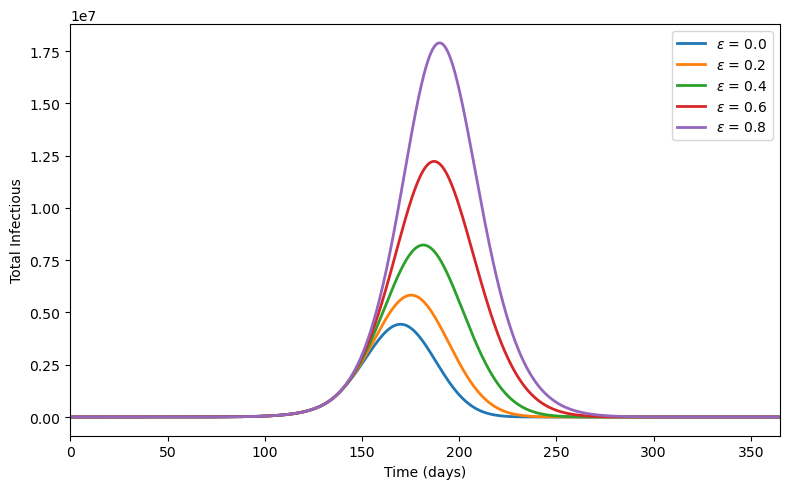

In [14]:
# =========================
# CELL 8: EFFECTS OF NPI COMPLIANCE AND BREAKTHROUGH SUSCEPTIBILITY
# =========================



# Part 8b: Varying residual susceptibility (epsilon)
epsilon_values = [0.0,0.2, 0.4, 0.6, 0.8]

fig8b, ax8b = plt.subplots(figsize=(8, 5))

for eps_val in epsilon_values:
    #print(f"Simulating ε = {eps_val}...")
    comp, peak, attack, _ = simulate_hpai_full(epsilon=eps_val, verbose=False)
    ax8b.plot(comp['times'], comp['I_total'],# / N_total, 
              linewidth=2, label=f'$\\epsilon$ = {eps_val}')

ax8b.set_xlabel(r"Time (days)")
ax8b.set_ylabel(r"Total Infectious")
#ax8b.grid(True, alpha=0.3)
ax8b.legend(fontsize=10)
ax8b.set_xlim(0, 365)
plt.tight_layout()
plt.show()
#fig8b.savefig(os.path.join(out_dir, "eps.png"), dpi=600)